# Mining

In this project I am focusing on optimizing gold recovery from ore processing by building and evaluating predictive models. Using data provided from industrial processes, the goal is to predict recovery rates at both the rougher and final output stages. The dataset consists of three files—training data, test data, and full data—with features such as metal concentrations and feed particle sizes. This project will complete a data science pipeline that consits of data preparation: Missing values were handled, and features unavailable in the test set were excluded. Outliers in concentration were identified and removed. Exploratory data analysis: Metal concentrations (Au, Ag, Pb) were analyzed across purification stages to understand trends, and particle size distributions were compared between train and test sets. Modeling: Linear Regression, Decision Tree, and Random Forest models were trained and tuned using cross-validation. A custom sMAPE metric was used for evaluation. Model selection and testing: The best model was evaluated on the real test set and compared to a dummy (baseline) model to validate its usefulness.
This project will demonstrate the application of supervised machine learning techniques in an industrial setting, with a focus on predictive accuracy and robustness of the models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.dummy import DummyRegressor

In [ ]:
train = pd.read_csv('/datasets/gold_recovery_train.csv')
test = pd.read_csv('/datasets/gold_recovery_test.csv')
full = pd.read_csv('/datasets/gold_recovery_full.csv')

In [ ]:
train.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [ ]:
test.head()

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


In [ ]:
full.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [ ]:
train.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,16788.000000,16788.000000,16490.000000,16789.000000,15339.000000,16794.000000,16677.000000,16715.000000,16794.000000,15553.000000,...,16731.000000,16747.000000,16768.000000,16767.000000,16775.000000,16775.000000,16775.000000,16776.000000,16757.000000,16775.000000
mean,4.716907,9.113559,8.301123,39.467217,67.213166,8.757048,2.360327,9.303932,2.687512,129.479789,...,19.101874,-494.164481,14.778164,-476.600082,15.779488,-500.230146,12.377241,-498.956257,18.429208,-521.801826
std,2.096718,3.389495,3.825760,13.917227,11.960446,3.634103,1.215576,4.263208,1.272757,45.386931,...,6.883163,84.803334,5.999149,89.381172,6.834703,76.983542,6.219989,82.146207,6.958294,77.170888
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000003,...,0.000000,-799.920713,0.000000,-800.021781,-0.423260,-799.741097,0.427084,-800.258209,0.024270,-810.473526
25%,3.971262,8.825748,6.939185,42.055722,62.625685,7.610544,1.641604,7.870275,2.172953,103.064021,...,14.508299,-500.837689,10.741388,-500.269182,10.977713,-500.530594,8.925586,-500.147603,13.977626,-501.080595
50%,4.869346,10.065316,8.557228,44.498874,67.644601,9.220393,2.453690,10.021968,2.781132,131.783108,...,19.986958,-499.778379,14.943933,-499.593286,15.998340,-499.784231,11.092839,-499.933330,18.034960,-500.109898
75%,5.821176,11.054809,10.289741,45.976222,72.824595,10.971110,3.192404,11.648573,3.416936,159.539839,...,24.983961,-494.648754,20.023751,-400.137948,20.000701,-496.531781,15.979467,-498.418000,24.984992,-499.565540
max,16.001945,17.031899,18.124851,53.611374,100.000000,19.552149,6.086532,22.317730,9.789625,251.999948,...,60.000000,-127.692333,28.003828,-71.472472,63.116298,-275.073125,39.846228,-120.190931,54.876806,-39.784927


In [ ]:
test.describe()

,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,5554.000000,5572.000000,5856.000000,5690.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,...,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,170.515243,8.482873,7.264651,1.321420,1481.990241,-509.057796,1486.908670,-511.743956,1468.495216,-509.741212,...,15.636031,-516.266074,13.145702,-476.338907,12.308967,-512.208126,9.470986,-505.017827,16.678722,-512.351694
std,49.608602,3.353105,0.611526,0.693246,310.453166,61.339256,313.224286,67.139074,309.980748,62.671873,...,4.660835,62.756748,4.304086,105.549424,3.762827,58.864651,3.312471,68.785898,5.404514,69.919839
min,0.000103,0.000031,5.650000,0.000003,0.000000,-799.773788,0.000000,-800.029078,0.000000,-799.995127,...,0.000000,-799.798523,0.000000,-800.836914,-0.223393,-799.661076,0.528083,-800.220337,-0.079426,-809.859706
25%,143.340022,6.411500,6.885625,0.888769,1497.190681,-500.455211,1497.150234,-500.936639,1437.050321,-501.300441,...,12.057838,-501.054741,11.880119,-500.419113,10.123459,-500.879383,7.991208,-500.223089,13.012422,-500.833821
50%,176.103893,8.023252,7.259333,1.183362,1554.659783,-499.997402,1553.268084,-500.066588,1546.160672,-500.079537,...,17.001867,-500.160145,14.952102,-499.644328,12.062877,-500.047621,9.980774,-500.001338,16.007242,-500.041085
75%,207.240761,10.017725,7.650000,1.763797,1601.681656,-499.575313,1601.784707,-499.323361,1600.785573,-499.009545,...,18.030985,-499.441529,15.940011,-401.523664,15.017881,-499.297033,11.992176,-499.722835,21.009076,-499.395621
max,274.409626,40.024582,15.500000,5.433169,2212.432090,-57.195404,1975.147923,-142.527229,1715.053773,-150.937035,...,30.051797,-401.565212,31.269706,-6.506986,25.258848,-244.483566,14.090194,-126.463446,26.705889,-29.093593


In [ ]:
full.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,22627.000000,22629.000000,22331.000000,22630.000000,20753.000000,22633.000000,22516.000000,22445.000000,22635.000000,21107.000000,...,22571.000000,22587.000000,22608.000000,22607.000000,22615.000000,22615.000000,22615.000000,22616.000000,22597.000000,22615.000000
mean,4.781559,9.095308,8.640317,40.001172,67.447488,8.923690,2.488252,9.523632,2.827459,140.277672,...,18.205125,-499.878977,14.356474,-476.532613,14.883276,-503.323288,11.626743,-500.521502,17.976810,-519.361465
std,2.030128,3.230797,3.785035,13.398062,11.616034,3.517917,1.189407,4.079739,1.262834,49.919004,...,6.560700,80.273964,5.655791,93.822791,6.372811,72.925589,5.757449,78.956292,6.636203,75.477151
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000003,...,0.000000,-799.920713,0.000000,-800.836914,-0.423260,-799.741097,0.427084,-800.258209,-0.079426,-810.473526
25%,4.018525,8.750171,7.116799,42.383721,63.282393,7.684016,1.805376,8.143576,2.303108,110.177081,...,14.095940,-500.896232,10.882675,-500.309169,10.941299,-500.628697,8.037533,-500.167897,13.968418,-500.981671
50%,4.953729,9.914519,8.908792,44.653436,68.322258,9.484369,2.653001,10.212998,2.913794,141.330501,...,18.007326,-499.917108,14.947646,-499.612292,14.859117,-499.865158,10.989756,-499.951980,18.004215,-500.095463
75%,5.862593,10.929839,10.705824,46.111999,72.950836,11.084557,3.287790,11.860824,3.555077,174.049914,...,22.998194,-498.361545,17.977502,-400.224147,18.014914,-498.489381,14.001193,-499.492354,23.009704,-499.526388
max,16.001945,17.031899,19.615720,53.611374,100.000000,19.552149,6.086532,22.861749,9.789625,274.409626,...,60.000000,-127.692333,31.269706,-6.506986,63.116298,-244.483566,39.846228,-120.190931,54.876806,-29.093593


In [ ]:
train.isna().sum().sort_values(ascending=False).head(10)

rougher.output.recovery               2573
rougher.output.tail_ag                2250
rougher.output.tail_sol               2249
rougher.output.tail_au                2249
secondary_cleaner.output.tail_sol     1986
rougher.input.floatbank11_xanthate    1904
final.output.recovery                 1521
primary_cleaner.input.sulfate         1307
primary_cleaner.input.depressant      1262
rougher.calculation.au_pb_ratio       1242
dtype: int64

In [ ]:
test.isna().sum().sort_values(ascending=False).head(10)

rougher.input.floatbank11_xanthate          353
primary_cleaner.input.sulfate               302
primary_cleaner.input.depressant            284
rougher.input.floatbank10_sulfate           257
primary_cleaner.input.xanthate              166
rougher.input.floatbank10_xanthate          123
rougher.input.feed_sol                       67
rougher.input.floatbank11_sulfate            55
rougher.input.feed_rate                      40
secondary_cleaner.state.floatbank3_a_air     34
dtype: int64

In [ ]:
full.isna().sum().sort_values(ascending=False).head(10)

rougher.output.recovery               3119
rougher.output.tail_ag                2737
rougher.output.tail_au                2736
rougher.output.tail_sol               2736
rougher.input.floatbank11_xanthate    2257
secondary_cleaner.output.tail_sol     2215
final.output.recovery                 1963
rougher.calculation.au_pb_ratio       1627
primary_cleaner.input.sulfate         1609
primary_cleaner.input.depressant      1546
dtype: int64

In [ ]:
train.isna().sum().sum()
test.isna().sum().sum()
full.isna().sum().sum()

36587

# 1.2

In [ ]:
C = train['rougher.output.concentrate_au']
F = train['rougher.input.feed_au']
T = train['rougher.output.tail_au']

calculated_recovery = ((C * (F - T)) / (F * (C - T))) * 100
true_recovery = train['rougher.output.recovery']
calculated_recovery = calculated_recovery.dropna()
#mask = true_recovery.notna() & calculated_recovery.notna()

abs_mean_difference = abs(calculated_recovery - true_recovery).mean()

print(f"Mean Absolute Difference: {abs_mean_difference}")


Mean Absolute Difference: 9.303415616264301e-15


I calculated recovery closely matches the provided recovery values, with a mean absolute difference of approximately 
9.30 * 10^(-15). So it's almost a zero. This confirms that the recovery formula has been implemented correctly and accurately reflects the true recovery values. The code calculates the rougher stage recovery using a given formula and compares it to the provided recovery values, showing that the implementation is correct based on a near-zero mean absolute difference.

# 1.3

In [ ]:
missing_columns = set(train.columns) - set(test.columns)
train[missing_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   rougher.output.tail_ag                              14610 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   primary_cleaner.output.concentrate_pb               16502 non-null  float64
 3   secondary_cleaner.output.tail_au                    16778 non-null  float64
 4   rougher.output.concentrate_sol                      16698 non-null  float64
 5   primary_cleaner.output.tail_sol                     16579 non-null  float64
 6   rougher.output.tail_au                              14611 non-null  float64
 7   secondary_cleaner.output.tail_ag                    16776 non-null  float64
 8   primary_cleaner.output.concentrate_ag               16778 non-null  float64


Several features are present in the training data but not in the test data. The differences must be handled before modeling to ensure consistent feature sets across both datasets. The code identifies which features are present in the training dataset but missing from the test dataset by comparing their column names and displaying them using .info()

# 1.4

In [ ]:
#common_columns = test.columns.intersection(test.columns)

In [ ]:
# train = train.fillna(train.median())
# test = test.fillna(test.median())

In [ ]:
# common_columns = test.columns.intersection(test.columns)
# full = full[common_columns]
# test = test[common_columns]

In [ ]:
print("Remaining missing values in train:", train.isna().sum().sum())
print("Remaining missing values in test:", test.isna().sum().sum())

Remaining missing values in train: 30320
Remaining missing values in test: 2360


# Step 2

# 2.1

In [ ]:
#filtering each column name

columns = ['rougher.output.concentrate_au',
           'rougher.output.concentrate_ag',
           'rougher.output.concentrate_pb',
           'primary_cleaner.output.concentrate_au',
           'primary_cleaner.output.concentrate_ag',
           'primary_cleaner.output.concentrate_pb',
           'secondary_cleaner.output.tail_au',
           'secondary_cleaner.output.tail_ag',
           'secondary_cleaner.output.tail_pb',
           'final.output.concentrate_au',
           'final.output.concentrate_ag',
           'final.output.concentrate_pb']

In [ ]:
# Group values by stage
stage_averages = {'Rougher Output': [full['rougher.output.concentrate_au'].mean(), full['rougher.output.concentrate_ag'].mean(), full['rougher.output.concentrate_pb'].mean()],
    'Primary Cleaner Output': [full['primary_cleaner.output.concentrate_au'].mean(), full['primary_cleaner.output.concentrate_ag'].mean(), full['primary_cleaner.output.concentrate_pb'].mean()],
    'Secondary Cleaner Output': [full['secondary_cleaner.output.tail_au'].mean(), full['secondary_cleaner.output.tail_ag'].mean(), full['secondary_cleaner.output.tail_pb'].mean()],
    'Final Output': [full['final.output.concentrate_au'].mean(), full['final.output.concentrate_ag'].mean(), full['final.output.concentrate_pb'].mean()]}
stage_averages

{'Rougher Output': [17.879538203033487, 10.874483745395448, 6.900646225251443],
 'Primary Cleaner Output': [29.2122887022116,
  7.691651764297089,
  8.921109840609049],
 'Secondary Cleaner Output': [4.041217642147423,
  13.375349370487982,
  5.3041069471642075],
 'Final Output': [40.001171896007136, 4.781559451695084, 9.095308105450266]}

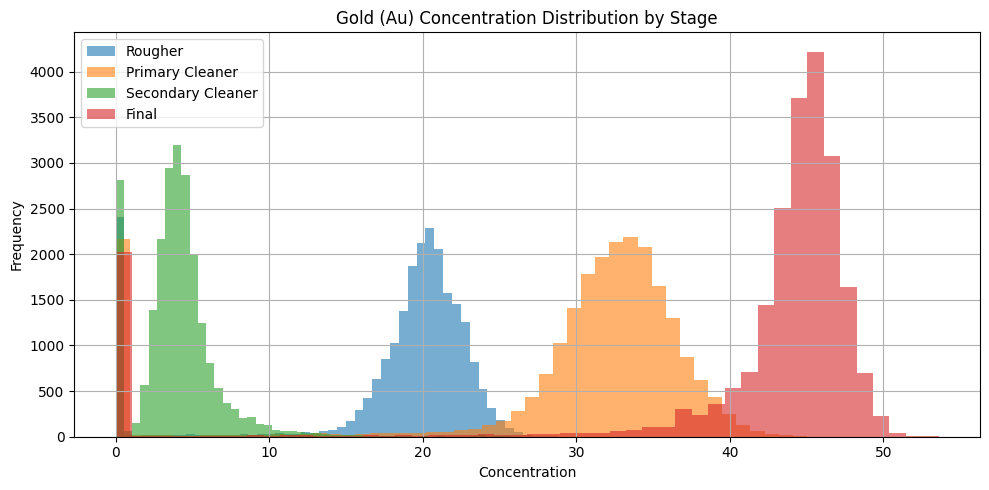

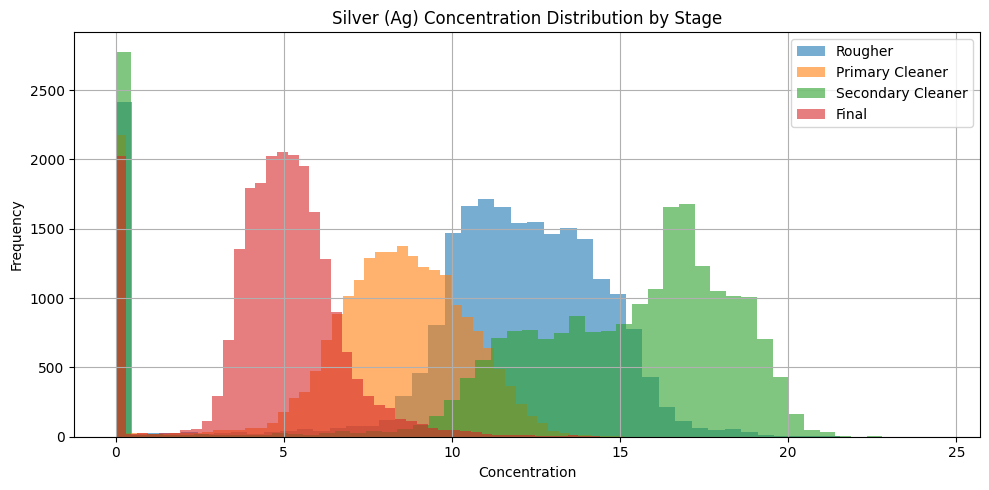

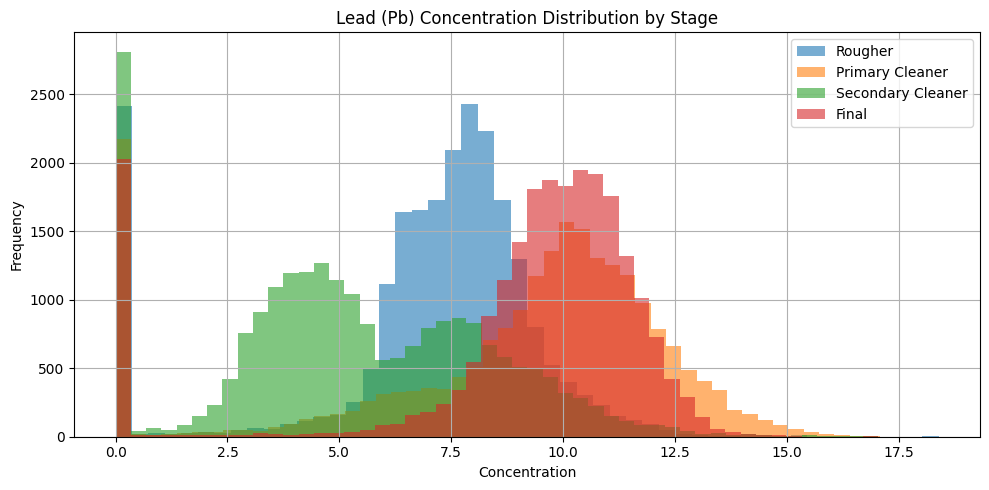

In [ ]:
# Plot Gold (Au)
plt.figure(figsize=(10, 5))
plt.hist(full['rougher.output.concentrate_au'], bins=50, alpha=0.6, label='Rougher')
plt.hist(full['primary_cleaner.output.concentrate_au'], bins=50, alpha=0.6, label='Primary Cleaner')
plt.hist(full['secondary_cleaner.output.tail_au'], bins=50, alpha=0.6, label='Secondary Cleaner')
plt.hist(full['final.output.concentrate_au'], bins=50, alpha=0.6, label='Final')
plt.title('Gold (Au) Concentration Distribution by Stage')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Silver (Ag)
plt.figure(figsize=(10, 5))
plt.hist(full['rougher.output.concentrate_ag'], bins=50, alpha=0.6, label='Rougher')
plt.hist(full['primary_cleaner.output.concentrate_ag'], bins=50, alpha=0.6, label='Primary Cleaner')
plt.hist(full['secondary_cleaner.output.tail_ag'], bins=50, alpha=0.6, label='Secondary Cleaner')
plt.hist(full['final.output.concentrate_ag'], bins=50, alpha=0.6, label='Final')
plt.title('Silver (Ag) Concentration Distribution by Stage')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Lead (Pb)
plt.figure(figsize=(10, 5))
plt.hist(full['rougher.output.concentrate_pb'], bins=50, alpha=0.6, label='Rougher')
plt.hist(full['primary_cleaner.output.concentrate_pb'], bins=50, alpha=0.6, label='Primary Cleaner')
plt.hist(full['secondary_cleaner.output.tail_pb'], bins=50, alpha=0.6, label='Secondary Cleaner')
plt.hist(full['final.output.concentrate_pb'], bins=50, alpha=0.6, label='Final')
plt.title('Lead (Pb) Concentration Distribution by Stage')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

For a better understanding on how the concentrations of gold (Au), silver (Ag), and lead (Pb) change throughout the purification process, I plotted separate histograms for each metal. Each plot compares the concentration distributions across the four main stages: Rougher Output, Primary Cleaner Output, Secondary Cleaner Output, and Final Output. Histograms provide a fuller view of how metal concentrations vary across different stages.
- Gold (Au) shows a clear shift toward higher concentrations as purification progresses, confirming the effectiveness of the process.
- Silver (Ag) shows a moderate improvement, with more overlap in distributions between stages.
- Lead (Pb) shows relatively little change, indicating that the purification process has minimal effect on lead concentration.

# 2.2

In [ ]:
train_size = train['rougher.input.feed_size']
test_size = test['primary_cleaner.input.feed_size']

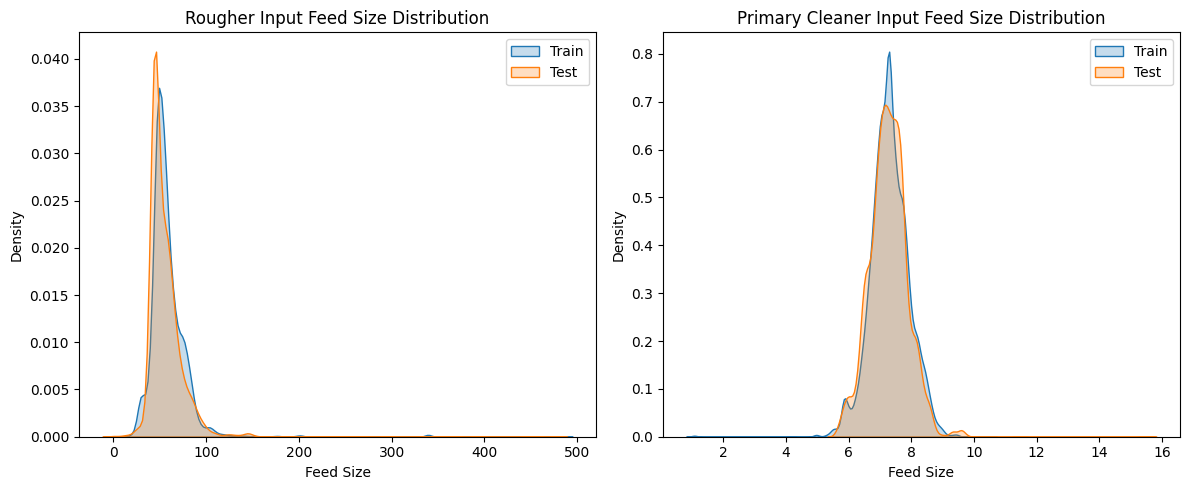

In [ ]:
plt.figure(figsize=(12, 5))

# Rougher input feed size
plt.subplot(1, 2, 1)
sns.kdeplot(train['rougher.input.feed_size'], label='Train', shade=True)
sns.kdeplot(test['rougher.input.feed_size'], label='Test', shade=True)
plt.title('Rougher Input Feed Size Distribution')
plt.xlabel('Feed Size')
plt.legend()

# Primary cleaner input feed size
plt.subplot(1, 2, 2)
sns.kdeplot(train['primary_cleaner.input.feed_size'], label='Train', shade=True)
sns.kdeplot(test['primary_cleaner.input.feed_size'], label='Test', shade=True)
plt.title('Primary Cleaner Input Feed Size Distribution')
plt.xlabel('Feed Size')
plt.legend()

plt.tight_layout()
plt.show()

I plotted the feed partical size for both training and test datasets to see if they are smiliar. the significant difference between them could lead to unrealiable model evaluation.

# 2.3

In [ ]:
#full = pd.read_csv('/datasets/gold_recovery_full.csv')

full['total_conc_raw'] = full[['rougher.input.feed_ag', 'rougher.input.feed_pb', 
                               'rougher.input.feed_sol', 'rougher.input.feed_au']].sum(axis=1)

full['total_conc_rougher'] = full[['rougher.output.concentrate_ag', 'rougher.output.concentrate_pb',
                                   'rougher.output.concentrate_sol', 'rougher.output.concentrate_au']].sum(axis=1)

full['total_conc_final'] = full[['final.output.concentrate_ag', 'final.output.concentrate_pb',
                                 'final.output.concentrate_sol', 'final.output.concentrate_au']].sum(axis=1)


Number of abnormal rows: 2342
Data cleaned. Remaining rows: 20374


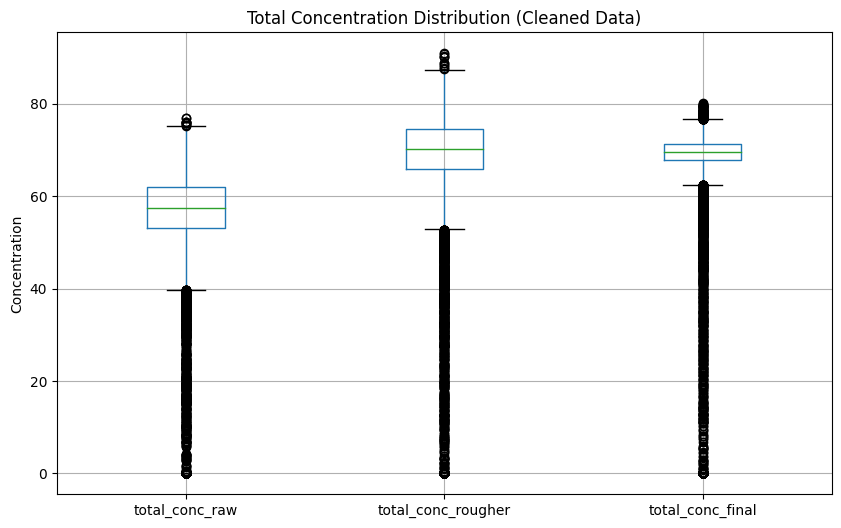

In [ ]:

#abnormal = full[(full['total_conc_raw'] > 1) | 
                #(full['total_conc_rougher'] > 1) | 
                #(full['total_conc_final'] > 1)]
abnormal = (full['total_conc_raw'] < 1e-5) | (full['total_conc_rougher'] < 1e-5) | (full['total_conc_final'] < 1e-5)

#print(f"Number of abnormal rows: {abnormal.shape[0]}")
print(f"Number of abnormal rows: {abnormal.sum()}")

#full_cleaned = full[(full['total_conc_raw'] <= 1) & 
                    #(full['total_conc_rougher'] <= 1) & 
                    #(full['total_conc_final'] <= 1)]
full_cleaned = full[~abnormal]        
print(f"Data cleaned. Remaining rows: {full_cleaned.shape[0]}")

full_cleaned[['total_conc_raw', 'total_conc_rougher', 'total_conc_final']].boxplot(figsize=(10, 6))
plt.title("Total Concentration Distribution (Cleaned Data)")
plt.ylabel("Concentration")
plt.grid(True)
plt.show()

After removing rows with near-zero metal concentrations, the dataset was cleaned and re-evaluated. The resulting boxplot shows a more accurate distribution of valid concentration values, improving data quality for further analysis and modeling. The total metal concentrations at three processing stages—raw input, rougher output, and final output—were recalculated and visualized using a boxplot. Rows with near-zero total concentration (less than 1e-5) at any stage were identified as abnormal and removed from the dataset.

# Step 3

# 3.1

In [ ]:
def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Avoid division by zero
    mask = denominator != 0
    return 100 * np.mean(numerator[mask] / denominator[mask])

def final_smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rougher = smape(y_true[0], y_pred[0])
    final = smape(y_true[1], y_pred[1])
    return 0.25 * rougher + 0.75 * final
 
# Make it a scorer (set greater_is_better=False for GridSearchCV to minimize)
smape_scorer = make_scorer(final_smape, greater_is_better=False)

# 3.2

In [ ]:
# Separate features and targets

target = ['rougher.output.recovery', 'final.output.recovery']
features = list(train.columns.intersection(test.columns).difference(target))
features.remove('date')


In [ ]:
# merge test set with full so it would include targets
test = test.merge(full[['date'] + target], how='inner', on='date')[features + target]

In [ ]:
train = train[features + target]

In [ ]:
# Handle mising values 
train = train.fillna(method='ffill')
test = test.fillna(method='ffill')

In [ ]:
X = train[features]
y = train[target]

# Split for quick validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)


# RandomForest

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf_model, param_grid_rf, scoring=smape_scorer, cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(X, y['final.output.recovery'])

best_rf = grid_rf.best_estimator_
print("Random Forest Best Params:", grid_rf.best_params_)
print("Random Forest Cross-validated sMAPE:", abs(grid_rf.best_score_))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Random Forest Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 50}
Random Forest Cross-validated sMAPE: 3.4954832128773567


# DecisionTree

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_model = DecisionTreeRegressor(random_state=42)
grid_dt = GridSearchCV(dt_model, param_grid_dt, scoring=smape_scorer, cv=5, n_jobs=-1, verbose=1)
grid_dt.fit(X, y['final.output.recovery'])

best_dt = grid_dt.best_estimator_
print("Decision Tree Best Params:", grid_dt.best_params_)
print("Decision Tree Cross-validated sMAPE:", abs(grid_dt.best_score_))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Decision Tree Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Decision Tree Cross-validated sMAPE: 2.7860922921468765


# LinearRegression

In [ ]:
lr_rougher = LinearRegression()
lr_final = LinearRegression()

lr_rougher.fit(X_train, y_train['rougher.output.recovery'])
lr_final.fit(X_train, y_train['final.output.recovery'])

lr_pred_rougher = lr_rougher.predict(X_valid)
lr_pred_final = lr_final.predict(X_valid)

lr_score = final_smape([y_valid['rougher.output.recovery'], y_valid['final.output.recovery']],
                       [lr_pred_rougher, lr_pred_final])
print(f"Linear Regression sMAPE: {lr_score:.2f}")

Linear Regression sMAPE: 13.33


# Test the Best Model

In [ ]:
# Best Decision Tree parameters from GridSearchCV
best_dt_params = {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}

# Train models for rougher and final output
dt_rougher = DecisionTreeRegressor(**best_dt_params, random_state=42)
dt_final = DecisionTreeRegressor(**best_dt_params, random_state=42)

dt_rougher.fit(train[features], train['rougher.output.recovery'])
dt_final.fit(train[features], train['final.output.recovery'])

# Predict on test set
pred_dt_rougher = dt_rougher.predict(test[features])
pred_dt_final = dt_final.predict(test[features])

# Evaluate on test set
dt_test_score = final_smape(
    [test['rougher.output.recovery'], test['final.output.recovery']],
    [pred_dt_rougher, pred_dt_final]
)

print(f"✅ Final sMAPE on Test Set (Decision Tree): {dt_test_score:.2f}")

✅ Final sMAPE on Test Set (Decision Tree): 18.54


In [ ]:
# Dummy models trained on full training set
dummy_rougher = DummyRegressor(strategy='mean')
dummy_final = DummyRegressor(strategy='mean')

dummy_rougher.fit(train[features], train['rougher.output.recovery'])
dummy_final.fit(train[features], train['final.output.recovery'])

# Dummy predictions
dummy_pred_rougher = dummy_rougher.predict(test[features])
dummy_pred_final = dummy_final.predict(test[features])

# Evaluate dummy model
dummy_score = final_smape([test['rougher.output.recovery'], test['final.output.recovery']],
                          [dummy_pred_rougher, dummy_pred_final])
print("⚠️ sMAPE of Dummy Regressor (Baseline):", dummy_score)

⚠️ sMAPE of Dummy Regressor (Baseline): 13.180697474259352
